# Implementation of GPR with signature kernel

In [179]:
#Parameters
T = 1.0  # total time
S = 0.95
N = 100 # number of time steps
M = 10   # number of paths to generate
depth = 8
# Parameter GBM
S0 = 100  # initial stock price
mu = 1.0  # drift coefficient
sigma = 0.2  # volatility coefficient
# Parameter noisy sinus
noise_level = 0.2 # noise level for noisy sinus data
lambda_1 = 0.1  # regularization parameter for ridge regression, with paths_1
lambda_2 = 0.1  # regularization parameter for ridge regression, with paths_2
data_type = 'gbm'  # 'gbm' or 'sinus', to choose the type of data to generate
#prediction_type = "future path"  # type of prediction to make, for whole path prediction use any other string
prediction_type = "whole path"  # type of prediction to make, for pointwise


## Generation of noisy, sinusoidal data

In [180]:

import numpy as np
import matplotlib.pyplot as plt

def generate_sinus_data(T=1, N=100, M=5, noise=True, noise_level=0.1):
    t = np.linspace(0, T, N)
    X_samples = np.zeros((M+1, N))
    X_samples[0, :] =  t # set initial stock price for all paths
    #generate and plot M paths
    if noise == True:
        for i in range(1, M+1):
            X = np.sin(2 * np.pi * t) + np.random.normal(0, noise_level, N)
            X_samples[i, :] = X
    else:
        for i in range(1, M+1):
            X = np.sin(2 * np.pi * t)
            X_samples[i, :] = X
    return X_samples

## Generation of geometric Brownian Motion paths

In [181]:
#Generation of syntatic data: geometric brownian motion
#generating Geometric Brownian Motion (GBM) paths

import numpy as np
import matplotlib.pyplot as plt

def generate_gbm_path(S0=100, mu=0.1, sigma=0.2, T=1, N=100):
    dt = T / N
    t = np.linspace(0, T, N)
    W = np.random.standard_normal(size=N)
    W = np.cumsum(W) * np.sqrt(dt)  # standard Brownian motion
    S = (mu - 0.5 * sigma**2) * t + sigma * W
    X = S0 * np.exp(S)
    X[0] = S0
    return X

def generate_gbm_data(S0=100, mu=0.1, sigma=0.2, T=1, N=100, M=5):
    t = np.linspace(0, T, N)
    X_samples = np.zeros((M+1, N))
    X_samples[0, :] =  t # set initial stock price for all paths
    #generate and plot M paths
    for i in range(1,M+1):    
        X = generate_gbm_path(S0, mu, sigma, T, N)
        X_samples[i, :] = X
    return X_samples


def stopping(path: np.ndarray, S: float)-> np.ndarray:
    t = np.linspace(0, T, N)
    path_truncated = path[t < S]  # sample path at time s
    stopped_value = path_truncated[-1]
    n_pad = len(path) - len(path_truncated)
    path_stopped = np.concatenate([path_truncated, np.full(n_pad, stopped_value)])
    return path_stopped


## In this version of the notebook, we perform GPR with the noisy sinusoidal data. If the reader wants to perform GPR on the GBM data, change generate_sinus_data -> generate_gbm_data

In [182]:
#Here the notation is as follows: train stands for the training data hence the stopped paths
#and test stands for the test data, i.e. the paths we want to predict hence the unstopped paths

#GBM
if data_type == 'gbm':
    Y_train = generate_gbm_data(S0=S0, mu=mu, sigma=sigma, T=T, N=N, M=M)
    Y_test = generate_gbm_data(S0=S0, mu=mu, sigma=sigma, T=T, N=N, M=1)
elif data_type == 'sinus':
    Y_train = generate_sinus_data(T=T, N=N, M=M, noise=True, noise_level=noise_level)
    Y_test = generate_sinus_data(T=T, N=N, M=1, noise=True, noise_level=noise_level)
else: 
    raise ValueError("data_type must be either 'gbm' or 'sinus'")
#Y_train = generate_sinus_data(T=T, N=N, M=M, noise=True, noise_level=noise_level)
#Y_test = generate_sinus_data(T=T, N=N, M=1, noise=True, noise_level=noise_level)
t = Y_train[0, :]  # time vector for plotting

X_train = Y_train.copy()
for i in range(1, M+1):
    X_train[i, :] = stopping(Y_train[i, :], S)
X_train[0, :] = t

X_test = Y_test.copy()
for i in range(1, 2):
    X_test[i, :] = stopping(Y_test[i, :], S)
X_test[0, :] = t


## Plotting the training (stopped) and test (unstopped) data

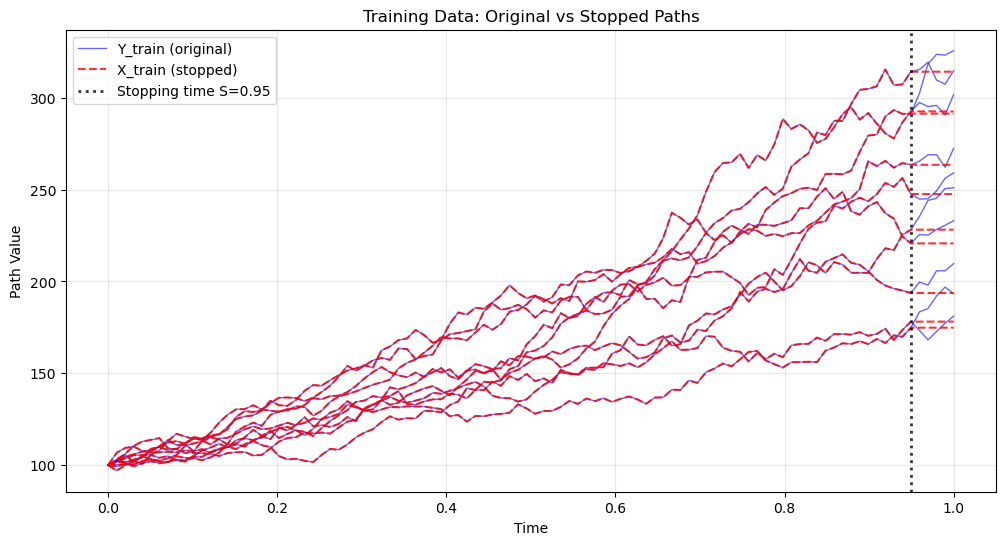

In [183]:
# Figure 1: Plot training data (stopped vs original paths)
plt.figure(figsize=(12, 6))

# Plot original training paths (Y_train)
for i in range(1, M+1):
    plt.plot(t, Y_train[i, :], 'b-', alpha=0.6, linewidth=1, label='Y_train (original)' if i == 1 else "")

# Plot stopped training paths (X_train)
for i in range(1, M+1):
    plt.plot(t, X_train[i, :], 'r--', alpha=0.8, linewidth=1.5, label='X_train (stopped)' if i == 1 else "")

# Add vertical line at stopping time
plt.axvline(x=S, color='black', linestyle=':', alpha=0.8, linewidth=2, label=f"Stopping time S={S}")

plt.xlabel('Time')
plt.ylabel('Path Value')
plt.title('Training Data: Original vs Stopped Paths')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

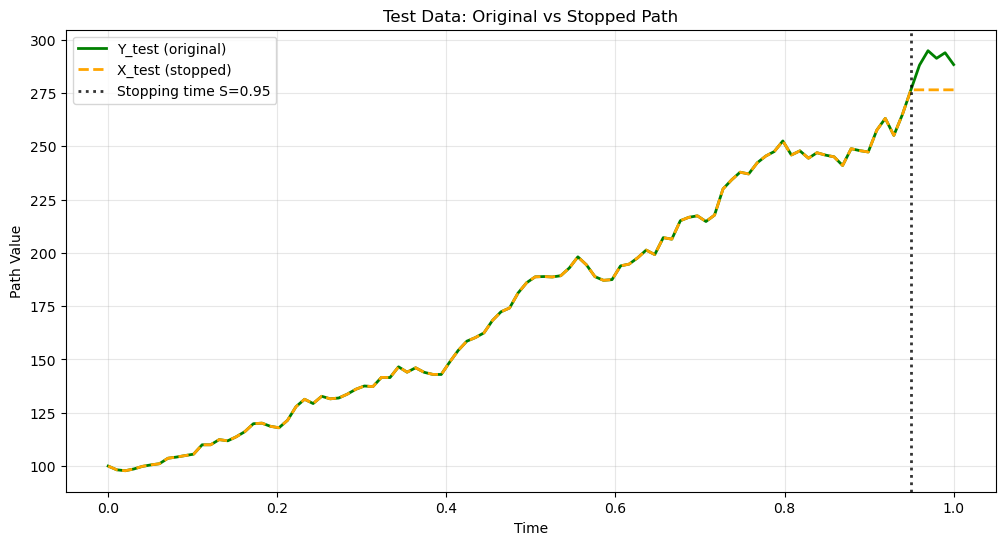

In [184]:
# Figure 2: Plot test data (stopped vs original paths)
plt.figure(figsize=(12, 6))

# Plot original test path (Y_test)
plt.plot(t, Y_test[1, :], 'g-', linewidth=2, label='Y_test (original)')

# Plot stopped test path (X_test)
plt.plot(t, X_test[1, :], 'orange', linestyle='--', linewidth=2, label='X_test (stopped)')

# Add vertical line at stopping time
plt.axvline(x=S, color='black', linestyle=':', alpha=0.8, linewidth=2, label=f"Stopping time S={S}")

plt.xlabel('Time')
plt.ylabel('Path Value')
plt.title('Test Data: Original vs Stopped Path')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Constructing a custom signature, inheriting from sklearn Kernel class to make it compatible with sklearn GPR

In [ ]:
from sklearn.gaussian_process.kernels import Kernel
from powersig.jax.algorithm import PowerSigJax
import jax.numpy as jnp


class PowerSigKernel(Kernel):
    """
    Simple signature kernel using PowerSig library for direct kernel matrix computation.
    """
    
    def __init__(self, depth=3, length_scale=1.0):
        self.depth = depth
        self.length_scale = length_scale

    def __call__(self, X, Y=None, eval_gradient=False):
        """Compute kernel matrix using PowerSig"""
        # For signature kernels, X should be (n_samples, path_length) 
        # where each row is a path of values in R
        X = np.asarray(X)
        if X.ndim == 1:
            X = X.reshape(1, -1)
        
        if Y is None:
            Y = X
        else:
            Y = np.asarray(Y)
            if Y.ndim == 1:
                Y = Y.reshape(1, -1)
        
        #normalize the data
        X_mean = np.mean(X, axis=1, keepdims=True)
        X_std = np.std(X, axis=1, keepdims=True)
        Y_mean = np.mean(Y, axis=1, keepdims=True)
        Y_std = np.std(Y, axis=1, keepdims=True)

        X  = (X - X_mean) / X_std
        Y  = (Y - Y_mean) / Y_std

            
        # Convert to JAX arrays and reshape for PowerSig
        n_samples_X, path_length_X = X.shape
        n_samples_Y, path_length_Y = Y.shape
        
        # Reshape to (n_samples, n_steps, 1) for 1D paths
        X_paths = jnp.array(X.reshape(n_samples_X, path_length_X, 1))
        
        # Initialize PowerSig
        powersig = PowerSigJax(self.depth)
        
        if np.array_equal(X, Y):
            # Same data, compute single kernel matrix
            K = np.array(powersig(X_paths))
            print("Computed kernel matrix K with shape:", K.shape)
        else:
            # Different data - combine and extract cross terms
            Y_paths = jnp.array(Y.reshape(n_samples_Y, path_length_Y, 1))
            combined_paths = jnp.concatenate([X_paths, Y_paths], axis=0)
            K_combined = np.array(powersig(combined_paths))
            K = K_combined[:n_samples_X, n_samples_X:]
        
        #return K* (self.length_scale ** 2)
    
        K_scaled = K* (self.length_scale ** 2)
        # for gradient evalution needed if WhiteKernel is added
        if eval_gradient:
            # Return kernel matrix and gradient w.r.t. hyperparameters
            # For now, return zero gradient (you can implement proper gradient later)
            gradient = np.zeros((K_scaled.shape[0], K_scaled.shape[1], 1))  # 1 hyperparameter (length_scale)
            return K_scaled, gradient
        else:
            return K_scaled

    def diag(self, X):
        return np.diag(self(X))

    def is_stationary(self):
        return False
    
    def __repr__(self):
        return f"PowerSigKernel(order={self.order})"

In [188]:
from sklearn.gaussian_process import GaussianProcessRegressor 
from sklearn.gaussian_process.kernels import WhiteKernel

kernel = PowerSigKernel(depth=depth, length_scale=10.0) + WhiteKernel(noise_level=5.0)  # Adding a small noise term for numerical stability
gpr = GaussianProcessRegressor(kernel=kernel, alpha=0.1)
gpr.fit(X_train[1:, :], Y_train[1:, :])

## Predict on test set
Y_pred, Y_std = gpr.predict(X_test[1:, :], return_std=True)
## Consider as the predicted values, the values of the predicted path for time points t > S
        

Computed kernel matrix K with shape: (10, 10)
Computed kernel matrix K with shape: (10, 10)
Computed kernel matrix K with shape: (10, 10)
Computed kernel matrix K with shape: (1, 1)
Computed kernel matrix K with shape: (1, 1)


In [189]:
if prediction_type == "future path":
    # For future path prediction we shift the predicition to match the test data at the stopping time S
    Y_pred_shifted = Y_pred.copy()
    t = Y_test[0, :]
    mask = t > S
    t_pred = t[mask]
    Y_pred_shifted = Y_pred.copy()
    Y_pred_shifted[0, mask] = Y_pred_shifted[0, mask] + (Y_test[1, N-len(t[mask])] - Y_pred_shifted[0, N-len(t[mask])])

## Plotting the predicted path from GPR with the signature kernel

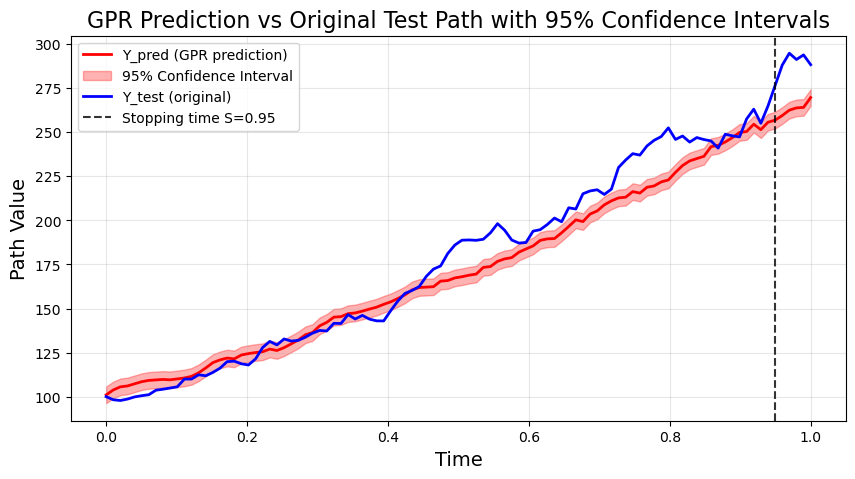

In [190]:
import matplotlib.pyplot as plt
# Plot Y_pred against time with 95% confidence intervals
plt.figure(figsize=(10, 5))

if prediction_type == "whole path":
    # Plot the predicted path
    plt.plot(t, Y_pred[0, :], 'r-', linewidth=2, label='Y_pred (GPR prediction)')
    

    # Add 95% confidence intervals (±1.96 * std for 95% CI)
    ci_95 = 1.96 * Y_std[0, :]
    plt.fill_between(t, 
                    Y_pred[0, :] - ci_95, 
                    Y_pred[0, :] + ci_95, 
                    alpha=0.3, color='red', label='95% Confidence Interval')

elif prediction_type == "future path":
    # Plot the predicted path
    plt.plot(t_pred, Y_pred_shifted[0, mask], 'r-', linewidth=2, label='Y_pred (GPR prediction)')

    # Add 95% confidence intervals (±1.96 * std for 95% CI)
    ci_95 = 1.96 * Y_std[0, mask]
    plt.fill_between(t_pred, 
                    Y_pred_shifted[0, mask] - ci_95, # Recall that Y_t is the posterior mean and hence a point estimate for the mean of the real gaussian distribution at that point, hence Y_t follows N(Y_t,sigma^2) so P(-z_0.95< Y_t/sigma < z_0.95) = 0.95. 
                    Y_pred_shifted[0, mask] + ci_95, 
                    alpha=0.3, color='red', label='95% Confidence Interval')

# For comparison, also plot the original test path and stopped test path

plt.plot(t, Y_test[1, :], 'b-', linewidth=2, label='Y_test (original)')

# Add vertical line at stopping time
plt.axvline(x=S, color='black', linestyle='--', alpha=0.8, label=f"Stopping time S={S}")

# Add labels and formatting
plt.xlabel('Time', fontsize=14)
plt.ylabel('Path Value', fontsize=14)
plt.title('GPR Prediction vs Original Test Path with 95% Confidence Intervals', fontsize=16)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

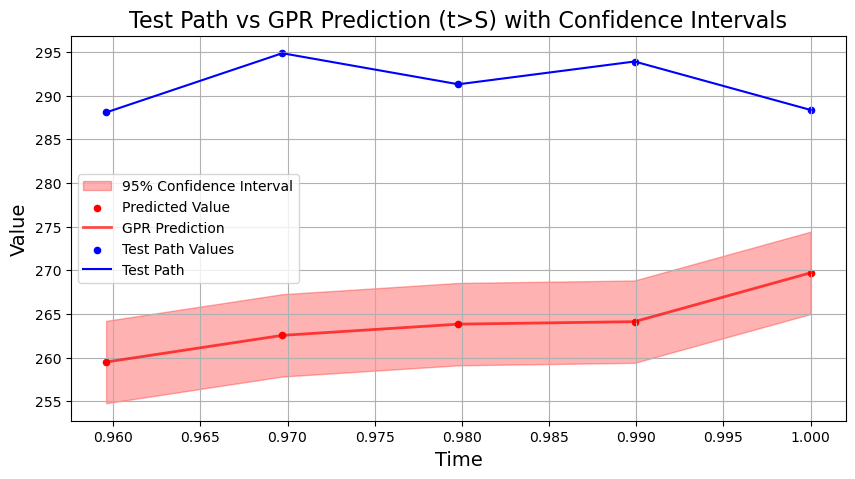

In [191]:
plt.figure(figsize=(10, 5))
# Show the predicted point as a red dot
t_pred = t[t>S]
if prediction_type == "whole path":
    # Add 95% confidence intervals first (so they appear behind the lines)
    ci_95 = 1.96 * Y_std[0, t>S]
    plt.fill_between(t_pred, 
                    Y_pred[0, t>S] - ci_95, 
                    Y_pred[0, t>S] + ci_95, 
                    alpha=0.3, color='r', label='95% Confidence Interval')

    # Then plot the predicted values
    plt.scatter(t_pred, Y_pred[0, t>S], color="red", s=20, marker="o", label="Predicted Value")
    plt.plot(t_pred, Y_pred[0, t>S], color="red", linestyle="-", alpha=0.7, linewidth=2, label="GPR Prediction")
elif prediction_type == "future path":
    # Add 95% confidence intervals first (so they appear behind the lines)
    ci_95 = 1.96 * Y_std[0, t>S]
    plt.fill_between(t_pred, 
                    Y_pred_shifted[0, mask] - ci_95, 
                    Y_pred_shifted[0, mask] + ci_95, 
                    alpha=0.3, color='red', label='95% Confidence Interval')

    # Then plot the predicted values
    plt.scatter(t_pred, Y_pred_shifted[0, mask], color="red", s=20, marker="o", label="Predicted Value")
    plt.plot(t_pred, Y_pred_shifted[0, mask], color="red", linestyle="-", alpha=0.7, linewidth=2, label="GPR Prediction")

# Plot the true test values
plt.scatter(t_pred, Y_test[1, t>S], color="blue", s=20, marker="o", label="Test Path Values")
plt.plot(t_pred, Y_test[1, t>S], label="Test Path", color="blue")

plt.xlabel("Time", fontsize=14)
plt.ylabel("Value", fontsize=14)
plt.title("Test Path vs GPR Prediction (t>S) with Confidence Intervals", fontsize=16)
plt.grid()
plt.legend()
plt.show()

# GPR Convergence Analysis: RMSE vs Number of Training Paths

In this section, we analyze how the GPR prediction quality (measured by RMSE) converges as we increase the number of training paths M, analogous to the ridge regression analysis in GBM_testing_normalized. In particular we conduct a complementary analysis of the condition number of the relevant matrices.

In [ ]:
# GPR CONVERGENCE ANALYSIS - analogous to GBM_testing_normalized
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
 

# Explicitly define N for convergence analysis (ensure consistency)
N_analysis = 200  # Number of time steps for analysis

# Define range of M values to test (number of training paths)
M_values = [10, 20, 50, 70, 100, 120, 150]
n_repetitions = 10  # Number of repetitions for each M value

# Storage for results
rmse_results = np.zeros((len(M_values), n_repetitions))
condition_numbers = np.zeros((len(M_values), n_repetitions))

# Fixed test data for consistent comparison
np.random.seed(42)  # For reproducible test data
if data_type == 'gbm':
    Y_test_fixed = generate_gbm_data(S0=S0, mu=mu, sigma=sigma, T=T, N=N_analysis, M=1)
elif data_type == 'sinus':
    Y_test_fixed = generate_sinus_data(T=T, N=N_analysis, M=1, noise=True, noise_level=noise_level)
# Create time vector and stopped test data
t_analysis = Y_test_fixed[0, :]
X_test_fixed = Y_test_fixed.copy()

X_test_fixed[1, :] = stopping(Y_test_fixed[1, :], S, T=T, N=N_analysis)
X_test_fixed[0, :] = t_analysis

print("Starting GPR convergence analysis...")
print(f"Using N = {N_analysis} time steps")
print(f"Testing M values: {M_values}")
print(f"Repetitions per M: {n_repetitions}")

kappa_A = np.zeros((len(M_values), 10))

# Compute condition number of ridge-regularized kernel matrix
def cond_ridge(K, alpha):
    K = np.array(K)
    A = K.T @ K + alpha * np.eye(K.shape[0])  # K is MxM here
    s = np.linalg.svd(A, compute_uv=False)
    # guard against zeros (shouldn’t occur with α>0, but just in case)
    return float(s.max() / s.min()) if np.all(s > 0) else np.inf

# Iterate over M values
for i, M_current in enumerate(M_values):
    
    for j in range(n_repetitions):
        # Generate new training data with M_current paths
        if data_type == 'gbm':
            Y_train_current = generate_gbm_data(S0=S0, mu=mu, sigma=sigma, T=T, N=N_analysis, M=M_current)
        elif data_type == 'sinus':
            Y_train_current = generate_sinus_data(T=T, N=N_analysis, M=M_current, noise=True, noise_level=noise_level)
        
        # Create stopped training data
        X_train_current = Y_train_current.copy()
        for k in range(1, M_current+1):
            X_train_current[k, :] = stopping(Y_train_current[k, :], S, T=T, N=N_analysis)
        X_train_current[0, :] = t_analysis
        
        # Train GPR
        alpha = 5.0
        kernel_current = PowerSigKernel(depth=depth, length_scale=10.0)
        gpr_current = GaussianProcessRegressor(kernel=kernel_current, alpha=alpha)
        gpr_current.fit(X_train_current[1:, :], Y_train_current[1:, :])
        
        # Get kernel matrix for condition number analysis

        K_train = kernel_current(X_train_current[1:, :])
        alpha_eff = alpha * M_current
        kappa_A[i, j] = cond_ridge(K_train, alpha_eff)

        condition_numbers[i, j] = np.linalg.cond(K_train)
        
        # Make prediction on fixed test data
        Y_pred_current, Y_std_current = gpr_current.predict(X_test_fixed[1:, :], return_std=True)
        
        # Compute RMSE
        if prediction_type == "whole path":
            rmse_current = np.sqrt(np.mean((Y_pred_current[0, :] - Y_test_fixed[1, :]) ** 2))
        elif prediction_type == "future path":
            mask = t_analysis > S
            rmse_current = np.sqrt(np.mean((Y_pred_current[0, mask] - Y_test_fixed[1, mask]) ** 2))
        
        rmse_results[i, j] = rmse_current



IndexError: boolean index did not match indexed array along axis 0; size of axis is 200 but size of corresponding boolean axis is 100

In [ ]:
# Plotting of statistics

# Compute statistics
average_rmse = np.mean(rmse_results, axis=1)
std_rmse = np.std(rmse_results, axis=1)
average_condition_numbers = np.mean(condition_numbers, axis=1)

# Plot 1: RMSE vs M
plt.figure(figsize=(10, 6))
plt.errorbar(M_values, average_rmse, yerr=std_rmse, marker='o', linestyle='-', 
             linewidth=2, markersize=8, capsize=5, capthick=2,
             color='blue', ecolor='lightblue', label='Average RMSE ± std')

plt.xlabel("Number of Training Paths (M)", fontsize=14)
plt.ylabel("Average RMSE", fontsize=14)
plt.title("GPR: Average RMSE vs Training Paths", fontsize=16)
plt.xticks(M_values)
plt.grid(True, alpha=0.7)
plt.legend(fontsize=16)
plt.tight_layout()
plt.show()

# Plot 2: Condition numbers
plt.figure(figsize=(10, 6))
plt.plot(M_values, average_condition_numbers, marker='s', linestyle='--', 
         linewidth=2, markersize=8, color='red', label=r'$(K^T K + M*\lambda I)$')
plt.xlabel("Number of Training Paths (M)", fontsize=14)
plt.ylabel("Average Condition Number", fontsize=14)
plt.title("GPR: Kernel Matrix Condition Numbers", fontsize=16)
plt.xticks(M_values)
plt.grid(True, alpha=0.7)
plt.legend(fontsize=16)
plt.tight_layout()
plt.show()

# Print summary
print("=== GPR CONVERGENCE ANALYSIS SUMMARY ===")
print(f"Initial RMSE (M={M_values[0]}): {average_rmse[0]:.4f} ± {std_rmse[0]:.4f}")
print(f"Final RMSE (M={M_values[-1]}): {average_rmse[-1]:.4f} ± {std_rmse[-1]:.4f}")
total_improvement = (average_rmse[0] - average_rmse[-1]) / average_rmse[0] * 100
print(f"Total improvement: {total_improvement:.2f}%")
print(f"Average condition number range: {np.min(average_condition_numbers):.1e} - {np.max(average_condition_numbers):.1e}")